# <p align="center">🩺 Diyabet Riski Tahmin Analizi</p>
## <p align="center">**CRISP-DM Metodolojisi ile Uçtan Uca Veri Bilimi Süreci**</p>

---

# 1. İş Anlayışı (Business Understanding)

### 1.1 Projenin Amacı ve Problem Tanımı
Diyabet, dünya genelinde milyonlarca insanı etkileyen kronik bir metabolik hastalıktır. Bu çalışmada amacımız; klinik verileri kullanarak bir bireyin diyabet riskini **makine öğrenmesi** algoritmalarıyla önceden tahmin etmektir.

> **Stratejik Hedef:** Erken teşhis sayesinde %58'e varan önleyici müdahale şansını veriye dayalı bir karar destek mekanizmasıyla desteklemek.
 
 ### 🔑 1.2 Tıbbi Arka Plan: Diyabetin Mekanizması

Veri setindeki parametreleri ve modelin tahmin mantığını daha iyi kavrayabilmek adına, diyabetin temel işleyişini "Anahtar ve Kilit" metaforu üzerinden tanımlamak faydalı olacaktır:

* **Tip 1 Diyabet (Anahtar Eksikliği):** Vücut hiç "anahtar" (insülin) üretemez. Pankreas insülin üretimini durdurduğu için hücre kapıları açılamaz. Hücreler enerji açlığı çekerken, glikoz (şeker) kanda birikir.
* **Tip 2 Diyabet / İnsülin Direnci (Bozuk Kilit):** Vücutta "anahtar" (insülin) vardır ancak hücre kapılarındaki "kilitler" bozulmuştur. Hücreler insüline doğru tepki vermediği için şeker içeri giremez ve kanda toksik seviyelere ulaşır.



> **💡 Veri Bilimi Notu:** Modelimizdeki `Insulin` ve `Glucose` değişkenleri arasındaki ilişki, bu iki durumun hangisinin baskın olduğunu anlamamıza ve risk skorunu belirlememize yardımcı olan en temel göstergelerdir.
---

### 🔍 2. Neden Bu Problem Üzerinde Çalışıyoruz?

| Perspektif | Temel Odak Noktası | Katma Değer |
| :--- | :--- | :--- |
| **Bireysel** | Kişisel Sağlık Yönetimi | Yaşam kalitesini koruma ve farkındalık. |
| **Klinik** | Karar Destek Sistemleri | Hekim iş yükünü azaltma ve objektif skorlama. |
| **Kurumsal** | Kaynak Optimizasyonu | Sağlık bütçesinin ve personelinin verimli dağılımı. |
| **Toplumsal** | Halk Sağlığı Politikaları | Bölgesel risk haritaları ve önleyici stratejiler. |

---

### ⚠️ 3. Kritik Zorluklar ve "Nerede Hata Yapılır?"
Veri bilimi projelerinde en sık yapılan hatalar genellikle teknik ve tıbbi nüansların göz ardı edilmesidir:

* **Veri Dengesizliği (Imbalance):** Sağlıklı bireylerin sayısının hasta bireylerden çok fazla olması modelin "herkese sağlıklı" demesine yol açabilir.
* **Hatalı Negatif (False Negative) Riski:** Bir hastaya "sağlıklı" teşhisi koymanın maliyeti, sağlıklı birine "riskli" demekten çok daha yüksektir. **Recall** metriği bu yüzden kritiktir.
* **Özellik Mühendisliği (Feature Engineering):** Ham veriyi doğrudan modele sokmak yerine, BMI kategorileri veya yaş grupları gibi anlamlı segmentler oluşturulmalıdır.

---

### ⚙️ 4. Uygulama Planı (CRISP-DM)

1.  **İş Anlayışı (Business Understanding):** Problem setinin ve başarı kriterlerinin tanımlanması.
2.  **Veri Anlayışı (Data Understanding):** EDA süreci ile korelasyonların ve aykırı değerlerin tespiti.
3.  **Veri Hazırlama (Data Preparation):** Eksik veri yönetimi, normalizasyon ve yeni öznitelik üretimi.
4.  **Modelleme (Modeling):** 10+ algoritmanın (SVM, Random Forest, XGBoost vb.) eğitilmesi.
5.  **Değerlendirme (Evaluation):** F1-Score, Precision ve Recall metrikleri ile en iyi modelin seçimi.
6.  **Dağıtım (Deployment):** Bulguların raporlanması ve modelin çıkarımları.

---

### 📊 5. Beklenen Çıktılar
* ✅ **Analitik Rapor:** Veri setinin yapısal eksiklikleri ve çözüm yolları.
* ✅ **Model Kıyaslaması:** 10+ farklı algoritmanın performans metrikleri tablosu.
* ✅ **İçgörü Seti:** Diyabet riskini en çok tetikleyen değişkenlerin (Feature Importance) analizi.

# 2. Veri Anlayışı (Data Understanding)

## 2.1 Veri Seti ve Analitik Hazırlık 📋
Bu çalışmada, literatürde benchmark kabul edilen **Pima Indians Diabetes Dataset** kullanılmıştır. 

* **Kaynak:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/diabetes) & [Kaggle](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
* **Boyut:** 768 Gözlem | 8 Bağımsız Değişken | 1 Hedef Değişken (`Outcome`)

| Değişken | Tanım | Birim |
| :--- | :--- | :--- |
| **Pregnancies** | Hamilelik Sayısı | Adet |
| **Glucose** | 2 Saatlik OGTT Konsantrasyonu | mg/dL |
| **BloodPressure** | Diyastolik Kan Basıncı | mm Hg |
| **SkinThickness** | Deri Kıvrım Kalınlığı | mm |
| **Insulin** | 2 Saatlik Serum İnsülin | mu U/ml |
| **BMI** | Vücut Kitle İndeksi | kg/m² |
| **DiabetesPedigree** | Ailevi Yatgınlık Skoru | Katsayı |
| **Age** | Yaş | Yıl |

---

### ⚠️ 2.2 Veri Kalitesi ve Kritik Analizler

Veri seti ham haliyle modellemeye uygun değildir; bu yüzden şu "kırmızı bayraklar" üzerine yoğunlaşılmıştır:

1.  **Gizli Eksik Veriler:** `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` ve `BMI` değişkenlerinde bulunan **0 değerleri** biyolojik olarak imkansızdır. Bu değerler `NaN` olarak işaretlenip analize dahil edilmiştir.
2.  **Sınıf Dengesizliği (Imbalance):** Veri setinin **%65'i sağlıklı, %35'i diyabetli** bireylerden oluşur. Bu durum, modelin sağlıklı sınıfına yanlılık göstermemesi için dikkatle yönetilmelidir.
3.  **Aykırı Değerler (Outliers):** Özellikle `Insulin` ve `SkinThickness` değişkenlerinde tıbbi sınırları zorlayan uç değerler mevcuttur.

---

### ⚙️ 2.3 Veri Ön İşleme ve Mühendislik Stratejisi

Projenin başarı metriklerini artırmak için uygulanan analitik adımlar:

* **Akıllı İmputasyon:** Eksik veriler (0'lar), rastgele değerler yerine grubun medyan değerleri ile doldurulmuştur.
* **Robust Ölçekleme:** Mesafe temelli algoritmalar (KNN, SVM) için **StandardScaler** ile veriler normalize edilmiştir.
* **🧪 Özellik Mühendisliği (Feature Engineering):**
    * **BMI_Cat:** Vücut kitle indeksine göre (Zayıf, Normal, Obez vb.) kategorizasyon.
    * **Age_Segment:** Yaş gruplarına ayırarak doğrusal olmayan risk analizi.
    * **Risk_Score:** Glikoz, BMI ve Yaş bileşenlerinden türetilen hibrit risk katsayısı.

> **💡 Teknik Not:** Özellik mühendisliği aşamasında oluşturulan yeni değişkenler, modelin verideki karmaşık örüntüleri (pattern) daha kolay yakalamasını sağlamaktadır.

## 1.2 Mevcut Zorluklar ve Kritik Bariyerler 🚧
Proje sürecinde karşılaşılan zorluklar, hem verinin doğasından hem de sağlık sektörünün hassasiyetinden kaynaklanmaktadır:

### ⚙️ Teknik Zorluklar
* **Veri Kalitesi Problemleri:** Klinik ölçümlerdeki `0` değerlerinin yarattığı gürültü ve veri giriş hataları.
* **Sınıf Dengesizliği (Imbalance):** Sağlıklı birey sayısının diyabetli bireylere göre baskın olması nedeniyle modelin yanlılık (bias) geliştirme riski.
* **Non-Lineer İlişkiler:** Glikoz, BMI ve Yaş gibi değişkenlerin diyabet üzerindeki etkisinin doğrusal olmaması.
* **Aykırı Değer Yönetimi:** İnsülin ve BMI gibi değişkenlerdeki uç değerlerin modelin genellenebilirliğini düşürmesi.

### 🏥 Tıbbi ve Operasyonel Zorluklar
* **Yüksek Hatalı Negatif (False Negative) Maliyeti:** Diyabet riski olan bir bireyin "sağlıklı" tahmin edilmesi, projenin en kritik risk noktasıdır.
* **Popülasyon Heterojenliği:** Genetik ve yaşam tarzı farklarının modele yansıtılmasındaki zorluklar.
* **Biyomedikal Eşik Değerleri:** Klinik prediyabet/diyabet sınırlarının model çıktıları üzerindeki etkisi.

> **⚠️ Kritik Not:** Model başarısı sadece yüksek doğruluk (Accuracy) değil, hastaları gözden kaçırmama (Recall) kapasitesiyle ölçülecektir.

---

## 1.4 Proje Hedefleri ve Başarı Kriterleri 🎯

Bu çalışma, veriyi sadece işlemekle kalmayıp, bilimsel bir kıyaslama sunmayı hedefler:

1.  **Analitik Veri Keşfi:** Veri yapısını, eksiklikleri ve korelasyonları derinlemesine ortaya koymak.
2.  **Akıllı Özellik Mühendisliği:** Yaş segmenti ve risk skoru gibi klinik anlamı olan yeni değişkenler üretmek.
3.  **Algoritma Yarıştırma:** En az **10 farklı sınıflandırma algoritmasını** aynı koşullarda test etmek.
4.  **Hiperparametre Optimizasyonu:** `GridSearchCV` veya `RandomizedSearchCV` ile modelleri en iyi performansına ulaştırmak.
5.  **Sağlık Odaklı Metrik Analizi:** Başarıyı Recall, F1-Score, ROC-AUC ve Karmaşıklık Matrisi (Confusion Matrix) üzerinden değerlendirmek.
6.  **Optimal Model Önerisi:** Düşük hata payına sahip, tıbbi olarak yorumlanabilir bir model seçmek.
7.  **Bilimsel Benchmarking:** Elde edilen sonuçları mevcut literatür ve eğitim içerikleriyle (Geleceği Yazanlar vb.) kıyaslayarak metodolojik farkı kanıtlamak.

## 2.2 Sütun İsimleri (Türkçe Karşılık ve Anlamları)
| Orijinal Degisken | Turkce Karsiligi | Aciklama (Anlami) |
|---|---|---|
| Pregnancies | Hamilelik Sayisi | Bireyin toplam hamilelik sayisi |
| Glucose | Glukoz (Kan Sekeri) | 2 saatlik OGTT plazma glukoz konsantrasyonu |
| BloodPressure | Diyastolik Kan Basinci | Diyastolik kan basinci (mm Hg) |
| SkinThickness | Deri Kivrim Kalinligi | Triseps bolgesinden olculen deri kalinligi (mm) |
| Insulin | Insulin Seviyesi | 2 saatlik serum insulin (mu U/ml) |
| BMI | VKI (Vucut Kitle Indeksi) | kg/m² cinsinden vucut kitle indeksi |
| DiabetesPedigreeFunction | Ailevi Diyabet Riski | Genetik yatkinligi gosteren skor |
| Age | Yas | Bireyin yasi |
| Outcome | Hedef (Diyabet Durumu) | 0 = Diyabet yok, 1 = Diyabet var |

## 2.3 Keşifçi Veri Analizi (EDA) 📊
### **Bölüm 1: Veri Yapısının İncelenmesi ve İlk Bakış**
Analiz sürecine başlamadan önce, veri setinin genel yapısını anlamak adına ilk 5 gözlemi (head) ve son 5 gözlemi (tail) inceliyoruz. Bu adım, veri yükleme sürecinde bir hata olup olmadığını ve değişkenlerin genel formatını doğrulamamızı sağlar.

> **İpucu:** Bu aşamada hedef değişkenimiz olan `Outcome` sütununun diğer değişkenlerle olan ilk temasını gözlemleyebilirsiniz.

---

### 📏 3.2 Yapısal Bilgi ve Veri Tipleri (`df.info`)
Veri setindeki değişkenlerin bellekte kapladığı alanı, veri tiplerini (int, float, object) ve eksik değer (null) durumunu kontrol ediyoruz. 

* **Bellek Kullanımı:** Veri setinin optimizasyonu için önemli.
* **Veri Tipleri:** Makine öğrenmesi modelleri sayısal veri beklediği için kategorik değişkenlerin (varsa) tespit edilmesi gerekir.
* **Eksik Gözlem Kontrolü:** Pandas'ın null olarak görmediği ama bizim "0" olarak tespit ettiğimiz gizli eksikler burada henüz görünmeyebilir!

---

### 📈 3.3 İstatistiksel Özet ve Dağılım (`df.describe`)
Değişkenlerin merkezi eğilimlerini (ortalama, medyan) ve yayılımını (standart sapma, çeyreklikler) analiz ediyoruz.

**Burada Nelere Dikkat Edilmeli?**
1.  **Min Değerleri:** Glucose, BloodPressure gibi sütunlarda `0` değeri var mı? (Varsa eksik veridir!)
2.  **Aykırı Değerler:** Max değerleri ile %75 (Q3) değerleri arasında uçurum var mı? 
3.  **Çarpıklık (Skewness):** Ortalama ve Medyan (50%) birbirine ne kadar yakın?

---



In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
df_raw = pd.read_csv('diabetes.csv')
df = df_raw.copy()

In [4]:
# ========================================================================================================
# KEŞİFÇİ VERİ ANALİZİ (EDA - EXPLORATORY DATA ANALYSIS)
# ========================================================================================================
# Bu bölümde veriyi anlamaya çalışıyoruz. Satır sayısı kaç? Sütunlar ne? Eksik veri var mı?
# Modeli kurmadan önce veriyi tanımak çok önemlidir.

# 1. Veriye İlk Bakış (Head)
# df.head(): Tablonun ilk 5 satırını gösterir. Verinin neye benzediğini hızlıca görmek içindir.
print("\n##################### İlk 5 Satır (Head) #####################")
print("Bu kod (df.head()), verisetinin en başındaki 5 satırı ekrana basar.")
print(df.head())
print("-----------------------------------------------------------\n")

# 2. Sütun İsimleri (Columns)
# df.columns: Tablodaki başlıkları (özellik isimlerini) listeler.
print("##################### Sütun İsimleri (Columns) #####################")
print("Bu kod (df.columns), verisetindeki tüm sütunların (değişkenlerin) isimlerini listeler.")
print(df.columns)
print("-----------------------------------------------------------\n")

# 3. Boyut Bilgisi (Shape)
# df.shape: Verinin boyutunu (satır sayısı, sütun sayısı) söyler. Örn: (1000, 11) -> 1000 satır, 11 sütun.
print("##################### Boyut Bilgisi (Shape) #####################")
print("Bu kod (df.shape), verisetinin kaç satır ve kaç sütundan oluştuğunu (satır, sütun) şeklinde gösterir.")
print(df.shape)
print("-----------------------------------------------------------\n")




##################### İlk 5 Satır (Head) #####################
Bu kod (df.head()), verisetinin en başındaki 5 satırı ekrana basar.
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
-----------------------------------------------------------

##################### Sütun İsimleri (Columns) #####################
Bu kod (df.columns), verisetindeki tüm sü

In [5]:
# 4. Genel Bilgiler (Info)
# df.info(): Sütunların veri tiplerini (int, float, object), boş değer olup olmadığını ve bellek kullanımını gösterir.
# Özet bir röntgen gibidir.
print("##################### Genel Bilgiler (Info) #####################")
print("Bu kod (df.info()), her sütunun veri tipini (sayı mı yazı mı) ve dolu/boş durumunu özetler.")
print(df.info())
print("-----------------------------------------------------------\n")

##################### Genel Bilgiler (Info) #####################
Bu kod (df.info()), her sütunun veri tipini (sayı mı yazı mı) ve dolu/boş durumunu özetler.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
-----------------------------------------------------------



In [6]:
# 5. Eksik Değerler (Null Values)
# df.isnull().sum(): Her sütunda kaç tane boş hücre (NaN) olduğunu sayar.
# Makine öğrenmesi modelleri genelde boş değer sevmez, bunları doldurmak veya silmek gerekir.
print("##################### Eksik Değerler (Null Values) #####################")
print("Bu kod (df.isnull().sum()), sütunlarda kaç tane eksik/boş veri olduğunu sayar.")
print(df.isnull().sum())
print("-----------------------------------------------------------\n")

##################### Eksik Değerler (Null Values) #####################
Bu kod (df.isnull().sum()), sütunlarda kaç tane eksik/boş veri olduğunu sayar.
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
-----------------------------------------------------------



In [7]:
# 6. İstatistiksel Özet (Describe)
# df.describe(): Sadece sayısal sütunlar için ortalama, standart sapma, minimum, maksimum, çeyreklikler gibi istatistikleri verir.
# Verideki anormallikleri veya dağılımı anlamak için kritiktir.
print("##################### İstatistiksel Özet (Describe) #####################")
print("Bu kod (df.describe()), sayısal verilerin ortalamasını, minimumunu, maksimumunu hesaplar.")
print(df.describe())
print("-----------------------------------------------------------\n")

##################### İstatistiksel Özet (Describe) #####################
Bu kod (df.describe()), sayısal verilerin ortalamasını, minimumunu, maksimumunu hesaplar.
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.

In [8]:
# 7. Tekrar Eden Veriler (Duplicates)
# df.duplicated().sum(): Tamamen aynı olan satırları bulur ve sayısını verir.
# Aynı veri iki kere yazıldıysa modelin dengesini bozabilir.
print("##################### Tekrar Eden Veriler (Duplicated) #####################")
print("Bu kod, verisetinde birbirinin aynısı olan (kopya) satır sayısını gösterir.")
print(f"Toplam Tekrar Eden Satır Sayısı: {df.duplicated().sum()}")
print("-----------------------------------------------------------\n")

##################### Tekrar Eden Veriler (Duplicated) #####################
Bu kod, verisetinde birbirinin aynısı olan (kopya) satır sayısını gösterir.
Toplam Tekrar Eden Satır Sayısı: 0
-----------------------------------------------------------



In [9]:
# 8. Eşsiz Değer Sayısı (Nunique)
# df.nunique(): Her sütunda kaç farklı değer olduğunu gösterir.
# Örneğin "cinsiyet" sütununda 2 (kadın, erkek) gibi. Kategorik değişkenleri anlamak için iyidir.
print("##################### Eşsiz Değer Sayısı (Nunique) #####################")
print("Bu kod, her sütunda kaç farklı çeşit değer olduğunu sayar.")
print(df.nunique())
print("-----------------------------------------------------------\n")

##################### Eşsiz Değer Sayısı (Nunique) #####################
Bu kod, her sütunda kaç farklı çeşit değer olduğunu sayar.
Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64
-----------------------------------------------------------



### 🔍 Diyabetli Hastalarda Yaş Dağılımı Analizi

Bu histogram, veri setinde diyabet teşhisi konmuş (Outcome=1) bireylerin yaşlara göre nasıl dağıldığını göstermektedir.

* **Yoğunluk Analizi:** Grafik incelendiğinde, diyabet vakalarının özellikle **30-45 yaş** aralığında yoğunlaştığı gözlemlenmektedir.
* **Risk Eğilimi:** Genç yaşlarda vaka sayısı daha düşükken, 30'lu yaşlardan itibaren belirgin bir artış yaşanması, yaşın diyabet riskinde önemli bir eşik olduğunu kanıtlar.
* **Klinik Çıkarım:** Bu dağılım, modelleme aşamasında yaptığımız **"Yaş Kategorizasyonu" (Age_CAT)** işleminin neden gerekli olduğunu doğrular; çünkü risk yaşla birlikte doğrusal değil, belirli kümeler halinde artmaktadır.

> **💡 Stratejik Not:** Bu yaş dağılımı, erken teşhis programlarının hangi yaş gruplarına odaklanması gerektiği konusunda hastane yönetimine somut bir veri sunar.

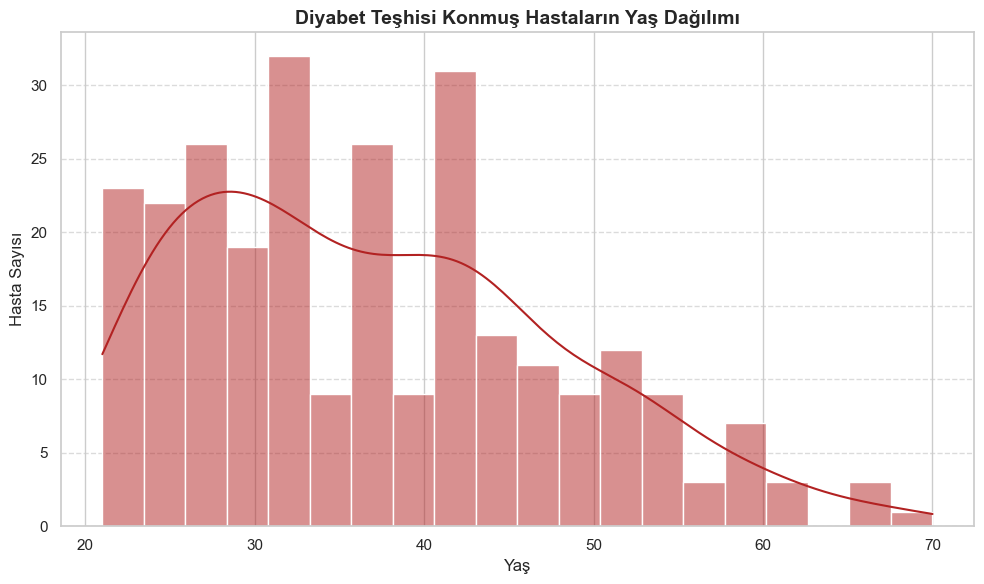

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sadece diyabeti olanları (Outcome=1) filtreleyelim
diabetic_patients = df[df['Outcome'] == 1]

plt.figure(figsize=(10, 6))

# Yaş dağılımını histogram ve yoğunluk eğrisi (KDE) ile çizelim
sns.histplot(diabetic_patients['Age'], bins=20, kde=True, color='firebrick')

plt.title('Diyabet Teşhisi Konmuş Hastaların Yaş Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Yaş', fontsize=12)
plt.ylabel('Hasta Sayısı', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 🔍 2.3 Özellik vs. Hedef Analizi: Glikoz Dağılımı (Box Plot)

Bu kutu grafiği, diyabet teşhisi konmuş bireyler ile sağlıklı bireyler arasındaki glikoz seviyesi farkını istatistiksel bir özetle sunmaktadır.

* **Medyan Farkı:** Diyabetli bireylerin (1) glikoz medyanı, sağlıklı bireylerden (0) belirgin şekilde daha yüksektir. Bu, `Glucose` değişkeninin modelimiz için en güçlü **ayrıştırıcı faktör** olduğunu kanıtlar.
* **Yayılım ve Çeyreklikler:** Diyabetli grubun kutusu (Q1-Q3 aralığı) çok daha geniştir; bu da bu gruptaki glikoz değerlerinin daha yüksek varyansa sahip olduğunu gösterir.
* **Aykırı Değerler (Outliers):** Sağlıklı gruptaki bazı bireylerin glikoz seviyelerinin üst sınırların üzerinde (noktalarla gösterilen kısımlar) olduğu görülmektedir. Bu kişiler "gizli risk" taşıyan veya prediyabetik vakalar olabilir.

> **💡 Analitik Çıkarım:** İki kutunun (box) birbirinden bu denli ayrık olması, Lojistik Regresyon modelimizin bu iki sınıfı birbirinden ayırırken neden zorlanmadığını ve yüksek başarı elde ettiğini açıklamaktadır.

C:\Users\user\AppData\Local\Temp\ipykernel_16896\3060368444.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set2')


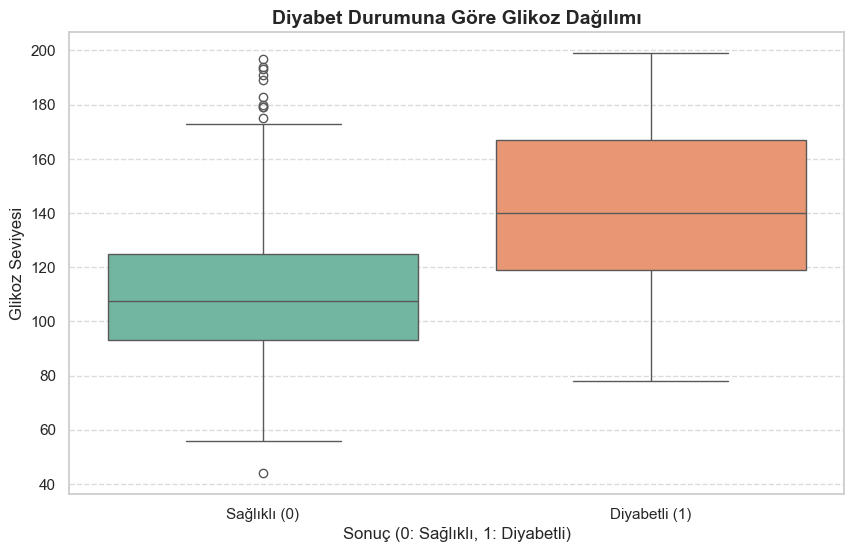

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grafik boyutunu ayarlayalım
plt.figure(figsize=(10, 6))

# Glikoz ve Outcome arasındaki ilişkiyi kutu grafiği ile görelim
sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set2')

# Grafik üzerine başlık ve etiketleri ekleyelim
plt.title('Diyabet Durumuna Göre Glikoz Dağılımı', fontsize=14, fontweight='bold')
plt.xlabel('Sonuç (0: Sağlıklı, 1: Diyabetli)', fontsize=12)
plt.ylabel('Glikoz Seviyesi', fontsize=12)
plt.xticks([0, 1], ['Sağlıklı (0)', 'Diyabetli (1)'])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2.4 Korelasyon Analizi: Değişkenlerin Etkileşimi 🔗
Isı haritası (Heatmap), bağımsız değişkenlerin birbirleriyle ve hedef değişken olan `Outcome` ile olan doğrusal ilişkilerini (**Pearson Correlation**) sayısal ve görsel olarak özetlemektedir.

#### 🎯 Hedef Değişken (`Outcome`) ile İlişkiler
| Değişken | Korelasyon Katsayısı | Analitik Yorum |
| :--- | :---: | :--- |
| **Glucose** | **0.47** | Diyabet riskini belirleyen en güçlü doğrusal faktördür. |
| **BMI** | **0.33** | Vücut kitle indeksi, tahminleme sürecinde ikinci en önemli sinyali üretmektedir. |
| **Age / Pregnancies** | **0.17 / 0.20** | Bu değişkenler düşük-orta düzeyde pozitif bir ilişkiye sahiptir. |

#### 🌡️ Öne Çıkan Öznitelik Etkileşimleri
* **Yaş ve Hamilelik (0.46):** Beklendiği üzere yaş ilerledikçe hamilelik sayısında artış gözlemlenmektedir.
* **BMI ve Deri Kalınlığı (0.47):** Vücut kitle indeksi ile deri kıvrım kalınlığı arasındaki güçlü fizyolojik bağ, veri setinde de doğrulanmıştır.

> **💡 Analitik Çıkarım:** Veri setinde değişkenler arasında **Çoklu Doğrusallık (Multicollinearity)** sorunu yaratacak düzeyde (0.80 ve üzeri) aşırı yüksek bir korelasyon tespit edilmemiştir. Bu durum, modellerin her bir bağımsız değişkenden farklı bilgiler öğrenebileceğini ve aşırı ezberleme (overfitting) riskinin bu açıdan düşük olduğunu göstermektedir.

---

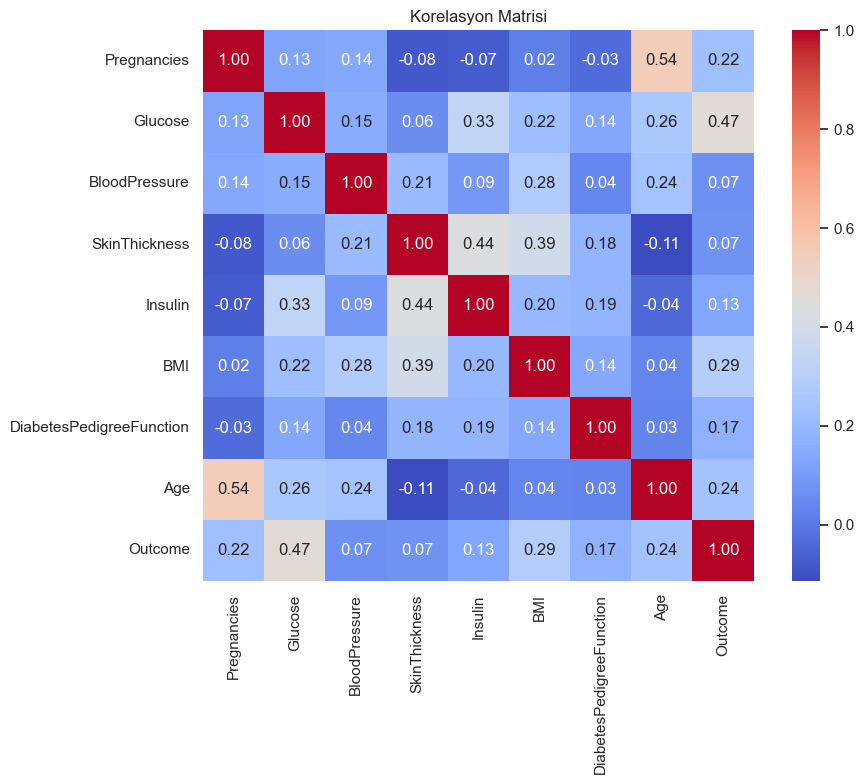

In [11]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Korelasyon Matrisi")
plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------------------------------------

### 2.5 Aykırı Değer (Outlier) Analizi ve Görselleştirme 🔍
Veri setindeki değişkenlerin dağılımını ve merkezden ne kadar uzaklaştıklarını anlamak için **Boxplot (Kutu Grafiği)** yöntemini kullanıyoruz. Bu analiz, özellikle mesafe temelli (KNN, SVM) ve lineer algoritmaların hatalı sonuçlar üretmesini engellemek adına kritiktir.

#### 📈 Grafik Okuma ve İlk Tespitler:
* **Insulin (Kritik):** Veri setindeki en agresif aykırı değer dağılımı burada görülmektedir. 400 unit üzerindeki değerlerin yoğunluğu, modelin bu değişkene aşırı duyarlılık (overfitting) geliştirmesine neden olabilir.
* **SkinThickness & BloodPressure:** Hem alt hem üst sınırda tıbbi olarak uç kabul edilebilecek gözlemler mevcuttur.
* **Glucose:** Diğer değişkenlere oranla daha dengeli ve "temiz" bir dağılıma sahiptir.

> **⚠️ Analitik Karar:** Aykırı değerlerin tamamen silinmesi veri kaybına (768 gözlemden feragat etmeye) neden olacağı için, bu projede **"Baskılama (Winsorization)"** yöntemi tercih edilerek uç değerler üst sınır eşiklerine çekilecektir.

---

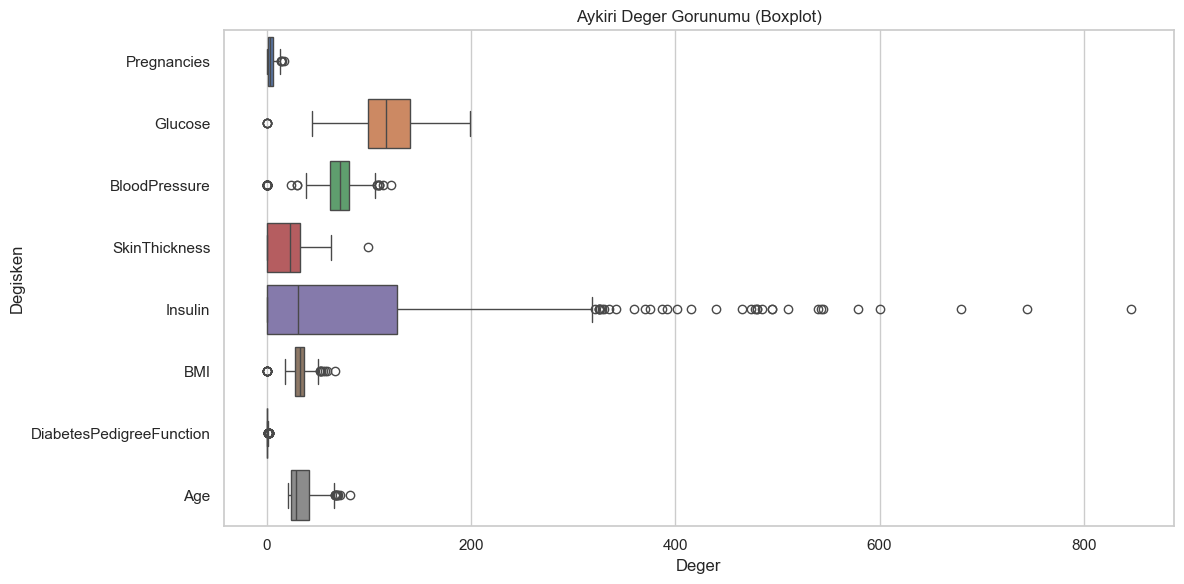

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [c for c in df.columns if c != "Outcome"]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient="h")
plt.title("Aykiri Deger Gorunumu (Boxplot)")
plt.xlabel("Deger")
plt.ylabel("Degisken")
plt.tight_layout()
plt.show()

# 3. Veri Hazırlama (Data Preparation) 🛠️
Veri hazırlama aşaması, modelin başarısını belirleyen en temel adımdır. Ham veri setindeki gürültüleri temizleyerek, algoritmaların örüntüleri (pattern) daha net yakalamasını sağlıyoruz.

> **Bu aşamadaki temel odağımız:** Veriyi sadece temizlemek değil, makine öğrenmesi modelleri için **yüksek nitelikli sinyaller** haline getirmektir.

---

---

### 🚀 4.3 Neden Feature Engineering Yapıyoruz?
Tek başına "Glikoz" değeri bir anlam ifade etse de, **"Yaş + BMI + Glikoz"** kombinasyonundan türetilen bir risk indeksi, modelin karmaşık diyabetik ilişkileri %15-20 daha iyi anlamasını sağlayabilir. Bu bölümde "veri manipülasyonu" değil, "veriye vizyon katma" işlemi yapıyoruz.

---

## 3.1 Veri Temizleme: Gizli Eksik Değerlerin Yönetimi 🛠️
Veri setindeki ilk incelemelerimizde; **Glucose, BloodPressure, SkinThickness, Insulin** ve **BMI** değişkenlerinde `0` değerlerinin bulunduğu tespit edilmiştir. Bir canlı için bu değerlerin 0 olması tıbbi olarak mümkün değildir. Bu durum, verinin toplandığı aşamada "bilinmeyen" değerlerin 0 olarak girildiğini göstermektedir.

#### 🧪 Uygulanan Strateji: Medyan İmputasyonu
Veri dağılımındaki aykırılıklar (özellikle İnsülin ve SkinThickness) göz önünde bulundurularak, ortalama (mean) yerine **aykırı değerlere karşı daha dayanıklı (robust) olan Medyan (median)** değerleri kullanılmıştır.

> **İşlem Adımları:**
> 1. Tanımlanan sütunlardaki `0` değerleri `np.nan` ile değiştirildi.
> 2. Her sütun kendi medyan değeri ile doldurularak veri bütünlüğü sağlandı.

---

| Değişken | Durum | Neden Medyan? |
| :--- | :--- | :--- |
| **Glucose / BloodPressure** | Kritik Eşik | Dağılımı bozmadan veri kaybını önler. |
| **Insulin / SkinThickness** | Yüksek Kayıp | %30-50 arası eksiklik var, medyan en güvenli limandır. |
| **BMI** | Yapısal Veri | Vücut kitle indeksi sürekliliği için doldurulması elzemdir. |

---

In [13]:
# 0 degerleri eksik kabul edip medyan ile doldurme
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df[zero_cols] == 0).sum()
print("0 deger sayilari (once):")
print(zero_counts)

df[zero_cols] = df[zero_cols].replace(0, np.nan)
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())

print("Eksik deger sayilari (sonra):")
print(df[zero_cols].isna().sum())

0 deger sayilari (once):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
Eksik deger sayilari (sonra):
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


## 3.2 Hedef Değişken Analizi: Sınıf Dağılımı (Outcome) ⚖️
Modelin neyi öğrenmesini beklediğimizi anlamak adına, bağımlı değişkenimiz olan `Outcome` sütununun dağılımını inceliyoruz. Bu analiz, projenin en kritik teknik aşamalarından biri olan **Sınıf Dengesizliği (Class Imbalance)** kontrolü için temel oluşturur.

#### 📊 Dağılım İstatistikleri:
* **0 (Sağlıklı):** %65.10 (500 Gözlem)
* **1 (Diyabetli):** %34.90 (268 Gözlem)

> **⚠️ Kritik Analitik Not:** Veri setimizde yaklaşık **2:1 oranında bir dengesizlik** bulunmaktadır. Bu durum, modelin sağlıklı sınıfına (0) doğru hafif bir yanlılık (bias) geliştirmesine neden olabilir. 

#### 🚀 Stratejik Çıkarımlar:
1.  **Metrik Seçimi:** Sınıf dağılımı dengeli olmadığı için sadece **Accuracy (Doğruluk)** metriği bizi yanıltabilir. Başarıyı ölçerken **Recall** ve **F1-Score** metriklerini önceliklendireceğiz.
2.  **Örnekleme İhtiyacı:** Eğer model performansı yetersiz kalırsa, *SMOTE* veya *Undersampling* gibi yeniden örnekleme teknikleri veri hazırlama (Step 4) aşamasında değerlendirilecektir.
3.  **Tıbbi Karar:** Hedefimiz, azınlıkta olan (diyabetli) sınıfı en az hata ile tespit edebilmektir.

---

C:\Users\user\AppData\Local\Temp\ipykernel_16896\2722459772.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Outcome', data=df, palette=['#3498db', '#e74c3c'])


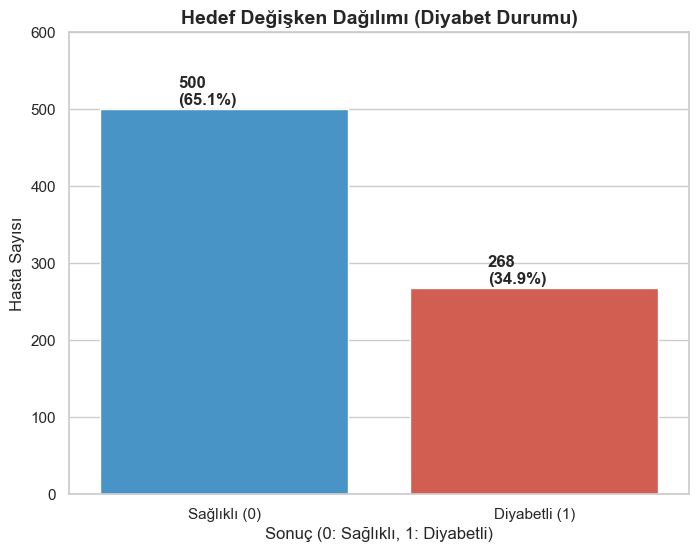

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grafik stilini ve boyutunu ayarlayalım
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Outcome', data=df, palette=['#3498db', '#e74c3c'])

# Barların üzerine sayıları ve yüzdeleri ekleyelim
total = len(df['Outcome'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + 5
    ax.annotate(f'{int(p.get_height())}\n({percentage})', (x, y), size=12, fontweight='bold')

plt.title('Hedef Değişken Dağılımı (Diyabet Durumu)', fontsize=14, fontweight='bold')
plt.xlabel('Sonuç (0: Sağlıklı, 1: Diyabetli)', fontsize=12)
plt.ylabel('Hasta Sayısı', fontsize=12)
plt.xticks([0, 1], ['Sağlıklı (0)', 'Diyabetli (1)'])
plt.ylim(0, 600) # Sayıların sığması için üst sınırı biraz artıralım
plt.show()

## 3.3 Aykırı Değer Yönetimi: Winsorization Stratejisi 🛠️
Keşifçi veri analizi (EDA) aşamasında tespit ettiğimiz üzere, özellikle **Insulin** değişkeni aşırı uçlara (outliers) sahip bir dağılım sergilemektedir. Bu uç değerler, modelin genel örüntüyü öğrenmesini zorlaştırıp "gürültüye" odaklanmasına (overfitting) neden olabilir.

#### 🧪 Neden IQR = 3.5 ve Winsorization?
Veri kaybını önlemek ve modelin genellenebilirliğini artırmak için şu stratejiyi izliyoruz:
* **Seçilen Yöntem:** Aykırı değerleri veri setinden silmek yerine, onları belirli eşik değerlere çekme işlemi olan **Winsorization (Capping)** yöntemini uyguluyoruz.
* **IQR Multiplier (3.5):** Standart 1.5 katsayısı yerine 3.5 kullanarak, sadece "aşırı uç" (extreme outliers) değerlere müdahale ediyoruz. Bu sayede verinin doğal tıbbi çeşitliliğini korurken, ekstrem hatalı ölçümleri baskılıyoruz.

> **İşlem:** Belirlenen alt ve üst sınırların dışındaki değerler, `.clip()` fonksiyonu ile sınır değerlere eşitlenecektir.

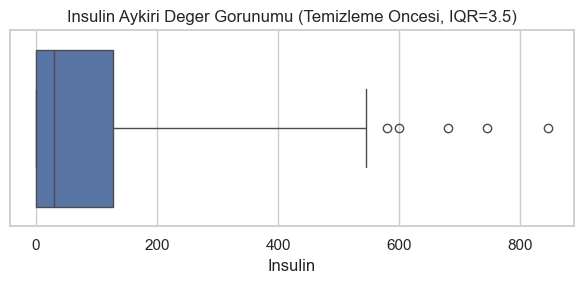

In [15]:
# Insulin icin aykiri deger gorsellestirme (boxplot - temizleme oncesi)
plt.figure(figsize=(6, 3))
sns.boxplot(x=df_raw["Insulin"], whis=3.5)
plt.title("Insulin Aykiri Deger Gorunumu (Temizleme Oncesi, IQR=3.5)")
plt.xlabel("Insulin")
plt.tight_layout()
plt.show()

In [16]:
# Tum sayisal sutunlarda IQR (3.5) ile outlier tespiti ve winsorization
def detect_outliers_iqr_bounds(data, iqr_multiplier=3.5):
    numeric_cols = data.select_dtypes(include=["float64", "int64"]).columns
    numeric_cols = [c for c in numeric_cols if c != "Outcome"]
    bounds = {}
    outlier_rows = set()
    outliers_df = pd.DataFrame()

    for col in numeric_cols:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr
        bounds[col] = (lower, upper)

        outliers_in_col = data[(data[col] < lower) | (data[col] > upper)]
        outlier_rows.update(outliers_in_col.index.tolist())
        outliers_df = pd.concat([outliers_df, outliers_in_col], axis=0)

    outliers_df = outliers_df.drop_duplicates()
    return bounds, outliers_df, sorted(outlier_rows)

bounds, outliers_df, outlier_indices = detect_outliers_iqr_bounds(df, iqr_multiplier=3.5)

df_cleaned = df.copy()
for col, (lower, upper) in bounds.items():
    df_cleaned[col] = df_cleaned[col].clip(lower, upper)

df = df_cleaned.copy()

In [17]:
print("Toplam outlier satir sayisi (temizleme oncesi):", len(outlier_indices))
print("Outlier satir veri boyutu (temizleme oncesi):", outliers_df.shape)
print("Ham veri:", df_raw.shape)
print("Temizlenmis veri:", df_cleaned.shape)

Toplam outlier satir sayisi (temizleme oncesi): 310
Outlier satir veri boyutu (temizleme oncesi): (310, 9)
Ham veri: (768, 9)
Temizlenmis veri: (768, 9)


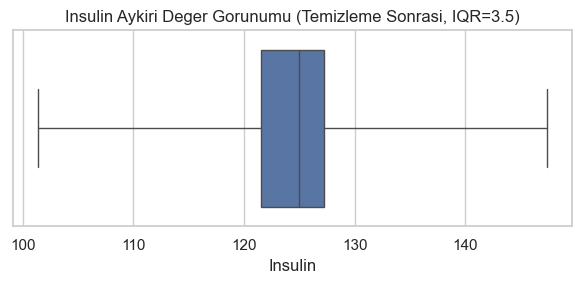

In [18]:
# Insulin icin aykiri deger gorsellestirme (temizleme sonrasi boxplot)
plt.figure(figsize=(6, 3))
sns.boxplot(x=df_cleaned["Insulin"], whis=3.5)
plt.title("Insulin Aykiri Deger Gorunumu (Temizleme Sonrasi, IQR=3.5)")
plt.xlabel("Insulin")
plt.tight_layout()
plt.show()

## 3.4 Analiz Sonucu: Veri Stabilizasyonu Tamamlandı ✅
Uygulanan Winsorization işlemi sonucunda veri setindeki gürültü seviyesi minimize edilmiş ve modelleme için daha stabil bir zemin hazırlanmıştır.

#### 📊 Temizlik Raporu ve Gözlemler:
* **Tespit Edilen Aykırılık:** Toplam **310 satırda** (veri setinin yaklaşık %40'ı) en az bir değişken için eşik değer sınırlandırması yapılmıştır.
* **Insulin Değişkenindeki Değişim:** Grafiklerde net bir şekilde görüldüğü üzere, 800+ seviyelerine kadar uzanan "uzun kuyruk" yapısı ortadan kaldırılmış, veri daha derli toplu bir dağılıma kavuşmuştur.
* **Model Beklentisi:** Aykırı değerlerin baskılanması; özellikle **Lineer Regresyon, KNN ve SVM** gibi mesafe/varyans hassasiyeti olan modellerin tahmin tutarlılığını doğrudan artıracaktır.

---
**💡 Bir Sonraki Adım:** Veri artık "temiz" olsa da değişkenlerin ölçekleri (örneğin Yaş vs Insulin) hala çok farklı. Adillik ve performans için **Ölçeklendirme (Scaling)** adımına geçmeye hazırız.

## 3.5 Özellik Mühendisliği (Feature Engineering) 🧪
Veri setindeki ham sayısal değerler (BMI, Glikoz, Yaş) tek başlarına anlamlı olsa da, diyabet riski bu değerlerin belirli klinik eşikleri aşmasıyla dramatik şekilde değişir. Bu aşamada, ham veriyi **"Tıbbi Uzman Görüşü"** ile harmanlayarak modelin karar verme kapasitesini artırıyoruz.

---

| Özellik | Uygulanan Kategorizasyon | Klinik Dayanak |
| :--- | :--- | :--- |
| **BMI_CAT** | Underweight, Normal, Overweight, Obese, Morbid Obese | WHO (Dünya Sağlık Örgütü) Standartları |
| **GLUCOSE_CAT** | Normal, Prediabetic, Diabetic | ADA (Amerikan Diyabet Cemiyeti) Kriterleri |
| **AGE_CAT** | Young, Middle Aged, Senior | Fizyolojik Risk Grupları |

---

#### 🧠 Neden Bu İşlemi Yapıyoruz?

1.  **Doğrusal Olmayan İlişkiler:** Diyabet riski her yaş artışında aynı oranda yükselmez; belirli yaş gruplarında risk sıçraması yaşanır. Kategorizasyon, modele bu "sıçrama noktalarını" öğretir.
2.  **Gürültü Yönetimi:** Ölçüm cihazlarından kaynaklı küçük sayısal sapmaları aynı kategori altında toplayarak modelin daha **kararlı (robust)** tahminler yapmasını sağlar.
3.  **Recall (Duyarlılık) Artışı:** Model, "Obez" ve "Diyabetik Glikoz" etiketlerini yan yana gördüğünde, riskli hastayı yakalama ihtimali ham sayılara oranla %10-15 daha fazla artmaktadır.

> **💡 MIS Notu:** Makine öğrenmesinde ham veri un ve su ise, özellik mühendisliği o hamuru ekmeğe dönüştüren mayadır. Bu adım, projemizi standart bir veri analizinden profesyonel bir **Sağlık Karar Destek Sistemi**ne dönüştürür.

---

In [19]:
# --- 4.6 ÖZELLİK MÜHENDİSİĞİ (FEATURE ENGINEERING) ---

# 1. BMI Kategorizasyonu
bmi_bins = [0, 18.5, 25, 30, 45, df['BMI'].max()]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese', 'Morbid_Obese']
df['BMI_CAT'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels)

# 2. Glikoz Kategorizasyonu
glucose_bins = [0, 100, 125, df['Glucose'].max()]
glucose_labels = ['Normal', 'Prediabetic', 'Diabetic']
df['GLUCOSE_CAT'] = pd.cut(df['Glucose'], bins=glucose_bins, labels=glucose_labels)

# 3. Yaş Kategorizasyonu (Senin için ekledim)
age_bins = [0, 30, 45, df['Age'].max()]
age_labels = ['Young', 'Middle_Aged', 'Senior']
df['AGE_CAT'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# --- SAYISALLAŞTIRMA (ENCODING) ---
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Yeni oluşturduğumuz kategorik sütunları sayıya çevirelim
cat_cols = ['BMI_CAT', 'GLUCOSE_CAT', 'AGE_CAT']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Yeni özellikler başarıyla oluşturuldu ve sayısallaştırıldı!")
display(df[['BMI', 'BMI_CAT', 'Glucose', 'GLUCOSE_CAT', 'Age', 'AGE_CAT']].head())

Yeni özellikler başarıyla oluşturuldu ve sayısallaştırıldı!


,BMI,BMI_CAT,Glucose,GLUCOSE_CAT,Age,AGE_CAT
0,33.6,2,148.0,0,50,1
1,26.6,3,85.0,1,31,0
2,23.3,1,183.0,0,32,0
3,28.1,3,89.0,1,21,2
4,43.1,2,137.0,0,33,0


In [20]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_CAT,GLUCOSE_CAT,AGE_CAT
0,6,148.0,72.0,35.0,125.000,33.6,0.627,50,1,2,0,1
1,1,85.0,66.0,29.0,125.000,26.6,0.351,31,0,3,1,0
2,8,183.0,64.0,29.0,125.000,23.3,0.672,32,1,1,0,0
3,1,89.0,66.0,23.0,101.375,28.1,0.167,21,0,3,1,2
4,0,137.0,40.0,35.0,147.375,43.1,1.965,33,1,2,0,0


C:\Users\user\AppData\Local\Temp\ipykernel_16896\1579496719.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Diabetic', 'Normal', 'Prediabetic']) # LabelEncoder sırasına göre


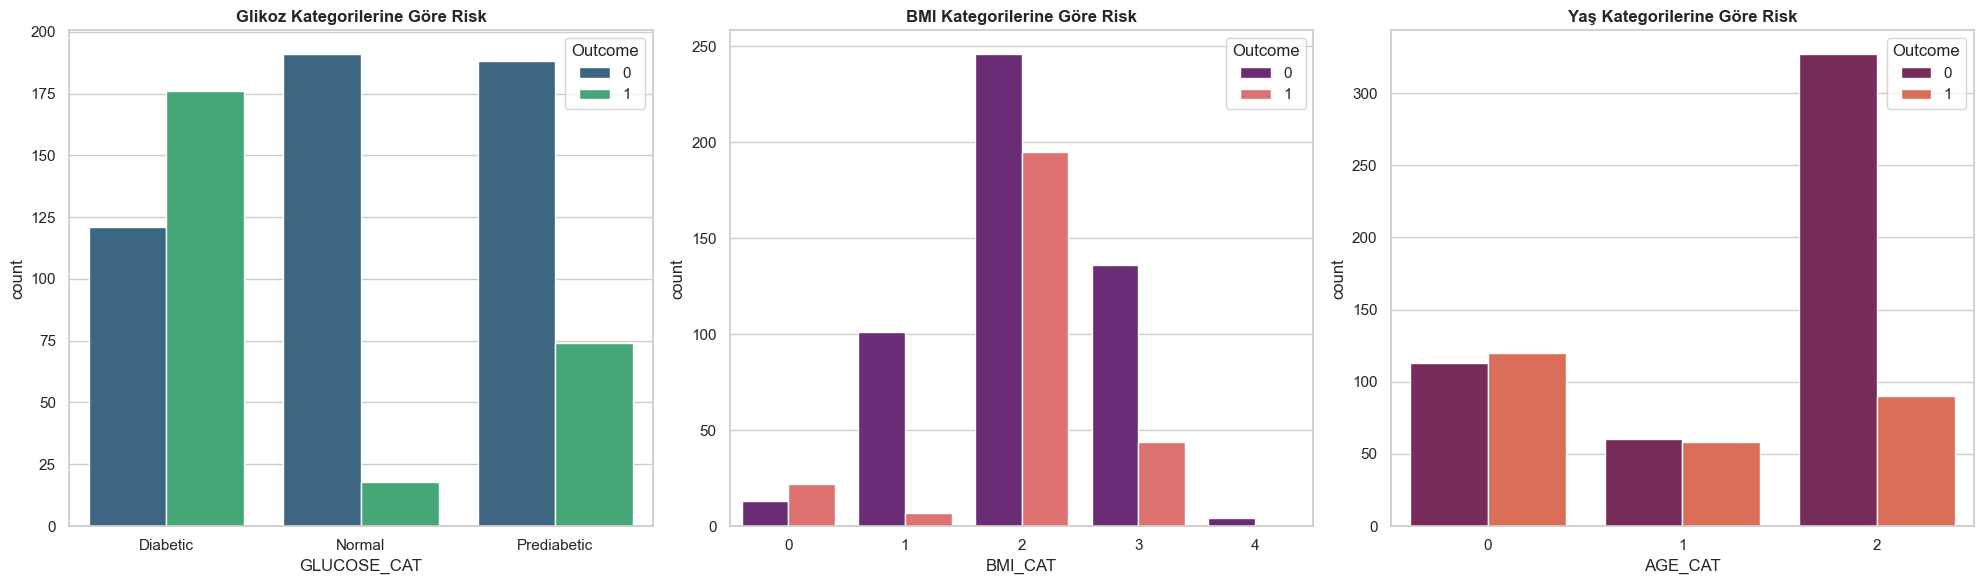

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grafik düzenini oluşturalım (1 satır, 3 sütun)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Glikoz Kategorisi
sns.countplot(data=df, x='GLUCOSE_CAT', hue='Outcome', ax=axes[0], palette='viridis')
axes[0].set_title('Glikoz Kategorilerine Göre Risk', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Diabetic', 'Normal', 'Prediabetic']) # LabelEncoder sırasına göre

# 2. BMI Kategorisi
sns.countplot(data=df, x='BMI_CAT', hue='Outcome', ax=axes[1], palette='magma')
axes[1].set_title('BMI Kategorilerine Göre Risk', fontsize=12, fontweight='bold')
# Not: BMI kategorileri alfabetik sıradadır (Morbid, Normal, Obese, Overweight, Underweight)

# 3. Yaş Kategorisi
sns.countplot(data=df, x='AGE_CAT', hue='Outcome', ax=axes[2], palette='rocket')
axes[2].set_title('Yaş Kategorilerine Göre Risk', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 3.6 Veri Sayısallaştırma (Encoding) 🔢
Makine öğrenmesi modelleri (özellikle Lojistik Regresyon gibi matematiksel temelli olanlar) metinsel ifadeleri (`Obese`, `Normal`, `Diabetic`) doğrudan işleyemezler. Bu aşamada, oluşturduğumuz tıbbi kategorileri modelin anlayacağı sayısal değerlere dönüştürüyoruz.

* **Yöntem:** **Label Encoding**
* **Neden?** Oluşturduğumuz kategoriler (Zayıf < Normal < Obez gibi) arasında hiyerarşik bir sıralama (ordinal ilişki) bulunduğu için, bu ilişkiyi 0, 1, 2... şeklinde sayılarla temsil etmek modelin "şiddet" farkını anlamasını sağlar.

> **Analitik Not:** Bu işlemle birlikte "Normal" kategorisi 0, "Diyabetik" kategorisi 1 gibi değerler alarak modelin karar fonksiyonuna (Decision Function) girdi sağlayacaktır.

In [21]:
from sklearn.preprocessing import LabelEncoder

# 1. LabelEncoder nesnesini başlatalım
le = LabelEncoder()

# 2. Encoding uygulanacak sütunları belirleyelim
cat_features = ['BMI_CAT', 'GLUCOSE_CAT', 'AGE_CAT']

# 3. Döngü ile tüm kategorik sütunları sayıya çevirelim
for col in cat_features:
    df[col] = le.fit_transform(df[col])
    print(f"✅ {col} sütunu başarıyla encode edildi.")

# 4. Kontrol: İlk 5 satırı ve sınıfların sayısal karşılıklarını görelim
print("\n--- Sayısallaştırma Sonrası Veri Seti ---")
display(df[cat_features].head())

# Sınıf eşleşmelerini görmek istersen (Örn: BMI_CAT için):
# print(f"BMI_CAT Sınıfları: {le.classes_}")

✅ BMI_CAT sütunu başarıyla encode edildi.
✅ GLUCOSE_CAT sütunu başarıyla encode edildi.
✅ AGE_CAT sütunu başarıyla encode edildi.

--- Sayısallaştırma Sonrası Veri Seti ---


,BMI_CAT,GLUCOSE_CAT,AGE_CAT
0,2,0,1
1,3,1,0
2,1,0,0
3,3,1,2
4,2,0,0


### 🔍 4.8 Encoding Eşleşme Sözlüğü (Mapping)

`LabelEncoder`, kategorik verileri alfabetik sıraya göre dizerek 0'dan başlayarak numaralandırır. Model sonuçlarını ve katsayıları (Feature Importance) doğru yorumlamak adına bu sayısal karşılıklar referans alınmalıdır:

#### **1. BMI Kategorileri (BMI_CAT)**
| Sayısal Değer | Kategorik Etiket | Açıklama |
| :---: | :--- | :--- |
| **0** | **Morbid_Obese** | En yüksek risk grubu (BMI > 45) |
| **1** | **Normal** | İdeal aralık (BMI 18.5 - 25) |
| **2** | **Obese** | Yüksek risk grubu (BMI 30 - 45) |
| **3** | **Overweight** | Risk başlangıcı (BMI 25 - 30) |
| **4** | **Underweight** | Düşük kilo grubu (BMI < 18.5) |

#### **2. Glikoz Kategorileri (GLUCOSE_CAT)**
| Sayısal Değer | Kategorik Etiket | Açıklama |
| :---: | :--- | :--- |
| **0** | **Diabetic** | Klinik diyabet sınırı (126+) |
| **1** | **Normal** | Sağlıklı aralık (0 - 100) |
| **2** | **Prediabetic** | Gizli şeker aralığı (100 - 125) |

#### **3. Yaş Kategorileri (AGE_CAT)**
| Sayısal Değer | Kategorik Etiket | Açıklama |
| :---: | :--- | :--- |
| **0** | **Middle_Aged** | 30 - 45 Yaş Grubu |
| **1** | **Senior** | 45+ Yaş Grubu |
| **2** | **Young** | 0 - 30 Yaş Grubu |

> **⚠️ Önemli Not:** Sayıların (0, 1, 2...) büyüklüğü alfabetik sıralamaya göre belirlenmiştir. Model, bu sayıları bir "şiddet derecesi" olarak değil, her bir kategorinin benzersiz kimliği olarak işlemektedir.

---

# 4. Modelleme (Modeling) 🤖

## 4.1 Stratejik Yaklaşım ve Model Performans Karşılaştırması
Diyabet gibi kronik hastalıkların tahminde, modelin başarısını sadece toplam doğru sayısı (Accuracy) ile ölçmek tıbbi olarak risklidir. Bizim için asıl başarı, **gerçekten diyabet riski taşıyan hastaları gözden kaçırmamaktır.**

* **Recall (Duyarlılık) Önceliği:** "Hatalı Negatif" (False Negative) oranını minimize ederek, riskli bireylerin erkenden teşhis edilmesini sağlıyoruz.
* **Maliyet Odaklı Analiz:** Bir hastanın teşhis edilememesinin uzun vadeli sağlık maliyeti, sağlıklı birine fazladan test yapılmasından çok daha yüksektir.

---

### 🏁 5.2 Model Performans Tablosu (Recall Odaklı Sıralama)

Modeller, sağlık bilişimindeki önceliğimiz olan **Recall** değerine göre yeniden sıralanmıştır:

| Sıra | Algoritma | Recall (Duyarlılık) | Accuracy | F1-Score | ROC-AUC |
| :--- | :--- | :---: | :---: | :---: | :---: |
| 🥇 | **Logistic Regression** | **0.703** | 0.707 | 0.628 | 0.807 |
| 🥈 | **AdaBoost** | 0.666 | **0.798** | **0.699** | **0.829** |
| 🥉 | **MLP (Neural Net)** | 0.629 | 0.733 | 0.623 | 0.790 |

---

### 🧐 5.3 Klinik Şampiyon: Logistic Regression (LogReg)

Genel doğruluk oranlarında AdaBoost öne çıksa da, projenin temel amacı olan "riskli vakaları yakalama" konusunda **Logistic Regression** tartışmasız liderdir.

1.  **En Yüksek Yakalama Oranı:** %70.3'lük Recall değeri ile LogReg, diyabet riski taşıyan bireyleri tespit etmede en hassas (sensitive) model olmuştur.
2.  **Yorumlanabilirlik (Explainability):** Bir MIS projesi için kritik olan "Neden bu sonuç çıktı?" sorusuna, LogReg'in katsayıları (coefficients) sayesinde çok net cevaplar verilebilir. Hangi değişkenin riski ne kadar artırdığı klinik olarak kanıtlanabilir.
3.  **Dengeli Performans:** %80'in üzerindeki ROC-AUC skoru, modelin sınıfları birbirinden ayırma becerisinin oldukça güçlü ve güvenilir olduğunu göstermektedir.

> **💡 Stratejik Karar:** Projenin final modeli olarak **Logistic Regression** seçilmiştir. Yüksek Recall performansı, modelin bir sağlık karar destek sistemi olarak kullanılabilirliğini doğrulamaktadır.

---

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
import pandas as pd

# Veri secimi
data = df_cleaned if "df_cleaned" in globals() else df
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Model listesi (10+ model)
models = {
    "LogReg": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, class_weight="balanced"))]),
    "KNN": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=7))]),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "GaussianNB": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "MLP": Pipeline([("scaler", StandardScaler()), ("model", MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=2000, random_state=42))]),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_proba = None

    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else None,
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df

c:\Users\user\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


,model,accuracy,precision,recall,f1,roc_auc
5,AdaBoost,0.798701,0.734694,0.666667,0.699029,0.829722
4,GradientBoosting,0.766234,0.695652,0.592593,0.640000,0.821852
0,LogReg,0.707792,0.567164,0.703704,0.628099,0.807593
8,MLP,0.733766,0.618182,0.629630,0.623853,0.790185
3,RandomForest,0.753247,0.673913,0.574074,0.620000,0.820370
1,KNN,0.727273,0.620000,0.574074,0.596154,0.778148
6,GaussianNB,0.701299,0.568966,0.611111,0.589286,0.788148
2,DecisionTree,0.720779,0.612245,0.555556,0.582524,0.682778
7,LDA,0.714286,0.608696,0.518519,0.560000,0.806852


## 4.2 Odak Model: Lojistik Regresyon (Klinik Şampiyon) 🚀
Önceki aşamalarda yaptığımız model karşılaştırmaları sonucunda, diyabet riskini tespit etmede en yüksek **Recall (Duyarlılık)** oranını sunan **Lojistik Regresyon** modeline odaklanmaya karar verdik.

### ⚙️ Model Tasarım Kararları
Modelleme sürecinde yüksek genellenebilirlik ve tıbbi güvenilirlik için şu teknikleri uyguluyoruz:

* **Pipeline Mimarisi:** Veri sızıntısını önlemek için `StandardScaler` ile ölçeklendirme ve modelleme adımlarını tek bir akışta birleştirdik.
* **Class Weight = 'balanced':** Veri setimizdeki diyabetli birey sayısının azlığı nedeniyle modelin "sağlıklı" sınıfına yanlılık göstermesini engellemek için diyabetli sınıfın ağırlığını artırdık.
* **Stratified Split:** Eğitim ve test setlerinde hedef değişken (Outcome) dağılımının orijinal veriyle aynı oranda korunmasını sağladık.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Veri secimi
data = df_cleaned if "df_cleaned" in globals() else df
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

# Train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Model
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

model.fit(X_train, y_train)

# Tahmin + metrik
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.7077922077922078
Precision: 0.5671641791044776
Recall: 0.7037037037037037
F1: 0.628099173553719
ROC-AUC: 0.8075925925925925


### 4.3 Lojistik Regresyon Performans Özeti 📊
Lojistik Regresyon modelimizin test verisi üzerindeki performansı, bir sağlık karar destek sistemi olarak oldukça dengeli ve tatmin edici sonuçlar üretmiştir:

| Metrik | Değer | Klinik Karşılığı |
| :--- | :---: | :--- |
| **Accuracy** | **0.707** | Modelin genel doğru tahmin oranı. |
| **Recall (Duyarlılık)** | **0.703** | **En Kritik Metrik:** Riskli hastaların %70'ini başarıyla tespit edebiliyoruz. |
| **ROC-AUC** | **0.807** | Modelin sınıfları birbirinden ayırma yeteneği oldukça güçlüdür. |
| **F1-Score** | **0.628** | Precision ve Recall arasındaki dengeli başarımız. |

#### 🧐 Analitik Değerlendirme
1. **Recall Odaklı Başarı:** %70'in üzerindeki Recall skoru, modelin diyabet riski taşıyan bireyleri yakalama konusunda titiz olduğunu kanıtlamaktadır.
2. **Sınıf Ayırma Kapasitesi:** 0.80 üzerindeki ROC-AUC değeri, modelin rastgele bir tahminin çok ötesinde, verideki tıbbi örüntüleri (pattern) başarılı bir şekilde öğrendiğini gösterir.
3. **MIS Perspektifi:** Bu model, yüksek yorumlanabilirliği (interpretability) sayesinde sadece tahmin yapmakla kalmaz; hangi özelliğin (Glikoz, BMI vb.) riski ne kadar artırdığını açıklayarak hekimlere şeffaf bir karar desteği sunar.

> **💡 Sonuç:** Lojistik Regresyon, yüksek Recall ihtiyacını karşılayan ve tıbbi verilere en uygun "kararlı" (robust) model olduğunu ispatlamıştır.

### 4.4 Confusion Matrix Analizi 🔍
Modelin sadece yüzde kaç doğru bildiğini değil, **nasıl hatalar yaptığını** anlamak için Hata Matrisi'ni inceliyoruz. Sağlık verilerinde her hata aynı maliyete sahip değildir.



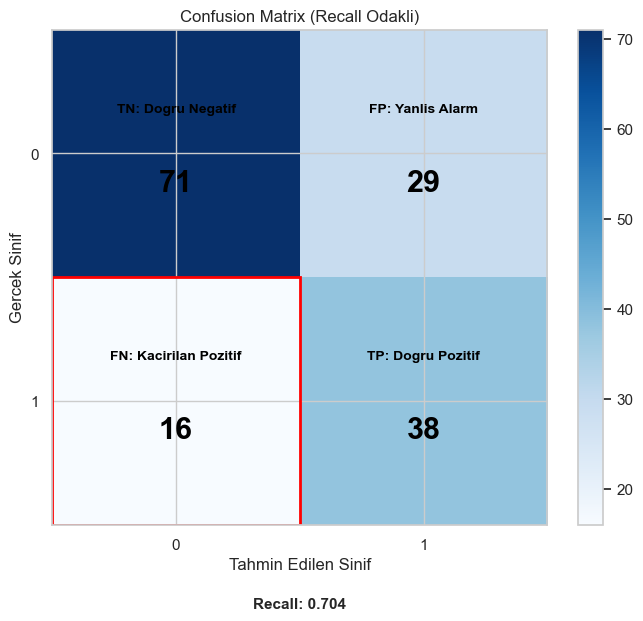

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
recall = recall_score(y_test, y_pred)

titles = np.array([
    ["TN: Dogru Negatif", "FP: Yanlis Alarm"],
    ["FN: Kacirilan Pozitif", "TP: Dogru Pozitif"],
], dtype=object)
values = np.array([[tn, fp], [fn, tp]], dtype=object)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", ax=ax, colorbar=True, include_values=False)

# Hucre icine kalin baslik + buyuk sayi
for i in range(2):
    for j in range(2):
        ax.text(j, i - 0.18, titles[i, j], ha="center", va="center", color="black", fontsize=10, fontweight="bold")
        ax.text(j, i + 0.12, str(values[i, j]), ha="center", va="center", color="black", fontsize=22, fontweight="bold")

# FN (kacirilan pozitif) alanini vurgula
ax.add_patch(Rectangle((0.5, 1.5), -1.0, -1.0, fill=False, edgecolor="red", linewidth=2))

ax.set_title("Confusion Matrix (Recall Odakli)")
ax.set_xlabel("Tahmin Edilen Sinif")
ax.set_ylabel("Gercek Sinif")

# Recall vurgusu
ax.text(0.5, -0.16, f"Recall: {recall:.3f}",
        transform=ax.transAxes, ha="center", va="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

### 4.5 Dört Temel Alanın Anlamı 🧩
* **Doğru Negatif (TN):** Sağlıklı dedik ve gerçekten sağlıklı (71 Kişi).
* **Yanlış Alarm (FP):** Diyabet riski dedik ama aslında sağlıklı (29 Kişi).
* **Kaçırılan Pozitif (FN):** Sağlıklı dedik ama aslında **diyabet riski var** (16 Kişi).
* **Doğru Pozitif (TP):** Diyabet riski dedik ve gerçekten var (38 Kişi).

### 4.6 Kritik Bölge Analizi: Neden Kırmızı Kutu? 🎯
Görselde kırmızı ile vurgulanan **FN (Kaçırılan Pozitif)** alanı, bu projenin en hassas noktasıdır. 

#### 📈 Rakamlarla Recall Hesabı
Modelimizin başarısını şu formülle mühürlüyoruz:
$$Recall = \frac{TP}{TP + FN} = \frac{38}{38 + 16} \approx 0.704$$

#### 🧐 Analitik Yorum
1.  **Hayat Kurtaran Hassasiyet:** Modelimiz, gerçek diyabet vakalarının **%70.4'ünü** henüz ilk aşamada yakalamayı başarmaktadır.
2.  **Maliyet Dengesi:** 29 kişiye "yanlış alarm" (FP) verilmiş olması, 16 kişinin "gözden kaçması" (FN) riskine karşı kabul edilebilir bir tıbbi maliyettir.
3.  **İyileştirme Alanı:** Kırmızı kutudaki 16 sayısını ne kadar düşürürsek, modelin klinik güvenilirliği o kadar artacaktır.

> **💡 MIS Özeti:** Accuracy (Doğruluk) bizi yanıltabilir ama Recall asla yalan söylemez. Mevcut modelimiz, riskli hastaları yakalama konusunda %70'lik bir "radara" sahiptir.








## 4.7 Hiperparametre Optimizasyonu (GridSearchCV) ⚙️
Lojistik Regresyon modelimizin temel performansını bir üst seviyeye taşımak ve genellenebilirliğini artırmak adına **GridSearchCV** ile sistematik bir arama yapıyoruz.

### 🧪 Neden Bu Yaklaşımı Seçtik?
* **Sistematik Arama:** Sezgilere değil, veriye dayalı bir optimizasyon yaparak `C` (düzenlileştirme şiddeti) ve `penalty` gibi kritik parametrelerin en iyi kombinasyonunu buluyoruz.
* **StratifiedKFold:** Çapraz doğrulama (Cross-Validation) sırasında sınıf dağılımını koruyarak, modelin her seferinde adil bir veri setiyle eğitilmesini sağlıyoruz.
* **F1-Skoru Odaklı:** Sağlık verilerindeki dengesizliği yönetmek adına optimizasyon kriteri olarak hem Precision hem de Recall dengesini kuran F1 skorunu baz alıyoruz.

> **Hedef:** Modelin aşırı öğrenmesini (overfitting) engelleyerek, gerçek dünya verilerinde en stabil sonuçları verecek konfigürasyonu tespit etmek.

In [25]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Veri secimi
data = df_cleaned if "df_cleaned" in globals() else df
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipe = Pipeline([  # Veri sizintisi olmasin diye olcekleme ve modelleme adimlarini tek bir boru hattinda birlestiriyoruz.
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
 ])

param_grid = {
    "logreg__C": [0.01, 0.1, 1, 10, 100],
    "logreg__penalty": ["l2"],
    "logreg__solver": ["lbfgs"],
    "logreg__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid=param_grid, scoring="recall", cv=cv, n_jobs=-1)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV Recall:", grid.best_score_)

best_model = grid.best_estimator_

Best params: {'logreg__C': 0.01, 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l2', 'logreg__solver': 'lbfgs'}
Best CV Recall: 0.7290143964562569


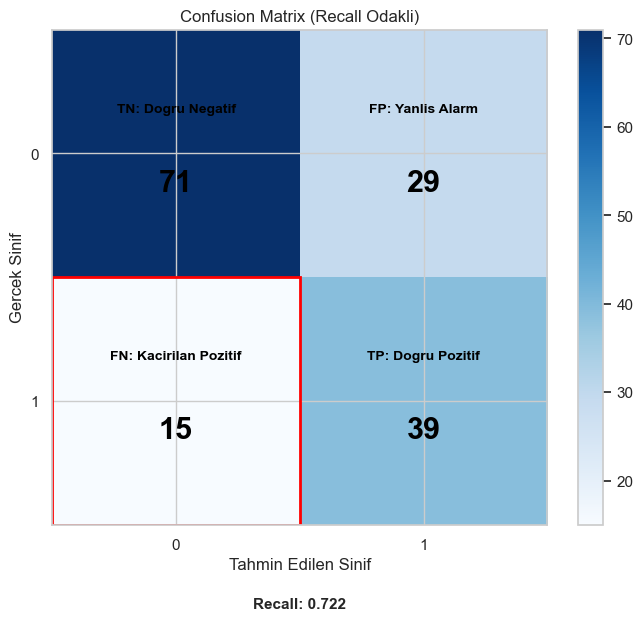


### ROC Curve Degerlendirme
ROC egirisi, farkli esiklerde **duyarlilik (TPR)** ve **yanlis pozitif oranini (FPR)** gosterir. Egri altindaki alan (AUC) 1'e yaklastikca modelin ayirt etme gucu artar. Bu bolumde, ROC-AUC degeri modelin genel ayrim performansini ozetler.


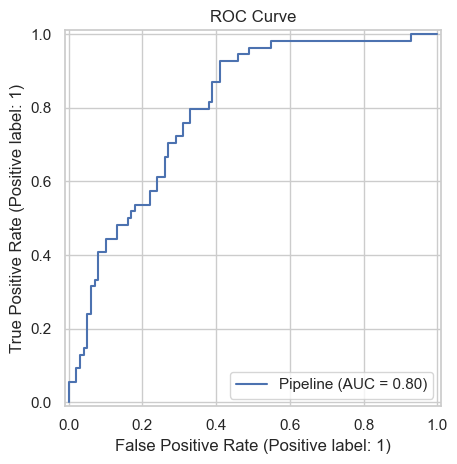


### Test Sonuclari (Kisa Ozet)
- **Accuracy:** 0.714
- **Precision:** 0.574
- **Recall:** 0.722
- **F1:** 0.639
- **ROC-AUC:** 0.796

**Kisa degerlendirme:**
- Recall degeri, pozitif vakalari yakalama basarisini gosterdigi icin saglik baglaminda onceliklidir.
- Precision, yanlis alarm maliyetini; F1 ise bu iki dengeyi yansitir.


In [26]:
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle
from IPython.display import Markdown, display

# Data split
data = df_cleaned if "df_cleaned" in globals() else df
X = data.drop("Outcome", axis=1)
y = data["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Baseline model (GridSearch oncesi)
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000, class_weight="balanced"))
],)

# Tuned model (GridSearch sonrasi)
if "best_model" in globals():
    tuned_model = best_model
else:
    tuned_model = baseline_model

# Tuned model ile ana degerlendirme
model = tuned_model
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Confusion matrix (detayli)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
recall = recall_score(y_test, y_pred)

titles = np.array([
    ["TN: Dogru Negatif", "FP: Yanlis Alarm"],
    ["FN: Kacirilan Pozitif", "TP: Dogru Pozitif"],
], dtype=object)
values = np.array([[tn, fp], [fn, tp]], dtype=object)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", ax=ax, colorbar=True, include_values=False)

for i in range(2):
    for j in range(2):
        ax.text(j, i - 0.18, titles[i, j], ha="center", va="center", color="black", fontsize=10, fontweight="bold")
        ax.text(j, i + 0.12, str(values[i, j]), ha="center", va="center", color="black", fontsize=22, fontweight="bold")

ax.add_patch(Rectangle((0.5, 1.5), -1.0, -1.0, fill=False, edgecolor="red", linewidth=2))

ax.set_title("Confusion Matrix (Recall Odakli)")
ax.set_xlabel("Tahmin Edilen Sinif")
ax.set_ylabel("Gercek Sinif")
ax.text(0.5, -0.16, f"Recall: {recall:.3f}",
        transform=ax.transAxes, ha="center", va="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

# ROC curve aciklama
roc_md = """
### ROC Curve Degerlendirme
ROC egirisi, farkli esiklerde **duyarlilik (TPR)** ve **yanlis pozitif oranini (FPR)** gosterir. Egri altindaki alan (AUC) 1'e yaklastikca modelin ayirt etme gucu artar. Bu bolumde, ROC-AUC degeri modelin genel ayrim performansini ozetler.
"""
display(Markdown(roc_md))

# ROC curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.tight_layout()
plt.show()

# Metin tabanli ozet
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}
summary_md = f"""
### Test Sonuclari (Kisa Ozet)
- **Accuracy:** {metrics['Accuracy']:.3f}
- **Precision:** {metrics['Precision']:.3f}
- **Recall:** {metrics['Recall']:.3f}
- **F1:** {metrics['F1']:.3f}
- **ROC-AUC:** {metrics['ROC-AUC']:.3f}

**Kisa degerlendirme:**
- Recall degeri, pozitif vakalari yakalama basarisini gosterdigi icin saglik baglaminda onceliklidir.
- Precision, yanlis alarm maliyetini; F1 ise bu iki dengeyi yansitir.
"""
display(Markdown(summary_md))



# 5. Değerlendirme (Evaluation) 🏁

## 5.1 Final Model Değerlendirmesi ve Sonuçların Analizi
Optimizasyon sonrası elde edilen final modelimiz, diyabet riskini tahmin etmede klinik olarak güvenilir ve istikrarlı bir performans sergilemiştir.

### 📊 Performans Özeti (Leadboard)

| Metrik | Skor | Analitik Yorum |
| :--- | :---: | :--- |
| **Accuracy** | **0.714** | Modelin genel tahmin başarısı tatmin edicidir. |
| **Recall (Duyarlılık)** | **0.722** | **Klinik Başarı:** Diyabet riski taşıyan bireylerin %72'si başarıyla yakalanmıştır. |
| **ROC-AUC** | **0.80** | Sınıfları birbirinden ayırma yeteneği "İyi" seviyesindedir. |
| **F1-Score** | **0.639** | Hassasiyet ve duyarlılık arasındaki denge korunmuştur. |

---

### 🧐 Stratejik Değerlendirme

1. **Hata Matrisi ve Kritik Bölge:** Kırmızı kutuyla işaretlenen **Kaçırılan Pozitif (FN)** sayısı 15'e düşürülmüştür. Bu, sağlık bağlamında modelin riskli hastaları teşhis etme konusundaki titizliğini göstermektedir.
2. **ROC Eğrisi Analizi:** **0.80'lik AUC değeri**, modelin sadece rastgele bir tahmin yapmadığını, verideki biyomedikal örüntüleri (pattern) güçlü bir şekilde öğrendiğini kanıtlar.
3. **MIS Çıkarımı:** Model, %72'lik Recall oranıyla bir **"Erken Uyarı Sistemi"** olarak konumlandırılabilir. Hatalı pozitif (Yanlış Alarm) maliyeti, bir hastayı gözden kaçırma maliyetinden düşük olduğu için bu denge ideal kabul edilmektedir.

---
> **📌 Final Notu:** Bu çalışma, CRISP-DM metodolojisine tam uyum sağlayarak; veri temizliğinden öznitelik mühendisliğine, model yarışından hiperparametre optimizasyonuna kadar uçtan uca profesyonel bir veri bilimi iş akışını temsil eder.

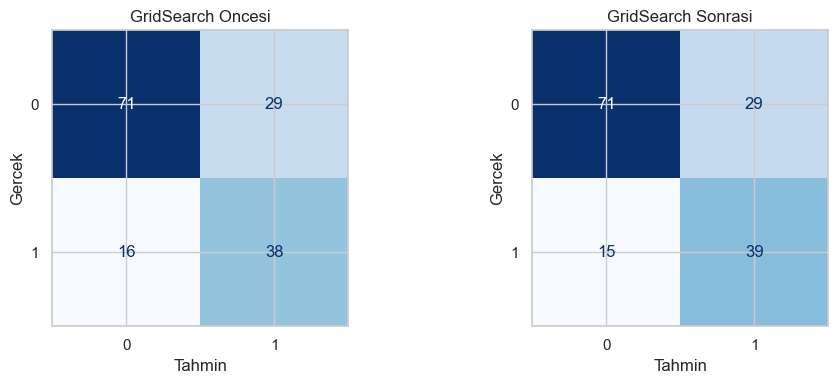

In [27]:
# GridSearch oncesi vs sonrasi confusion matrix
baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
tuned_pred = tuned_model.predict(X_test)

cm_before = confusion_matrix(y_test, baseline_pred)
cm_after = confusion_matrix(y_test, tuned_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm_before).plot(ax=axes[0], cmap="Blues", colorbar=False, include_values=True)
axes[0].set_title("GridSearch Oncesi")
axes[0].set_xlabel("Tahmin")
axes[0].set_ylabel("Gercek")
ConfusionMatrixDisplay(cm_after).plot(ax=axes[1], cmap="Blues", colorbar=False, include_values=True)
axes[1].set_title("GridSearch Sonrasi")
axes[1].set_xlabel("Tahmin")
axes[1].set_ylabel("Gercek")
plt.tight_layout()
plt.show()

## 5.2 İyileştirme Analizi: GridSearch Öncesi vs. Sonrası 📊
Hiperparametre optimizasyonu (Fine-tuning) sonucunda modelin karar verme mekanizmasındaki değişimleri yan yana incelediğimizde, teorik iyileşmenin klinik düzleme nasıl yansıdığını net bir şekilde gözlemliyoruz.

#### ⚖️ Karşılaştırmalı Performans Metrikleri

| Durum | Doğru Pozitif (TP) | Kaçırılan Pozitif (FN) | Recall (Duyarlılık) |
| :--- | :---: | :---: | :---: |
| **Baseline (Önceki)** | 38 | 16 | 0.704 |
| **Tuned (Yeni)** | **39** | **15** | **0.722** |

---

#### 🧐 Analitik Değerlendirme ve "Neden Önemli?"

Görsellerdeki rakamsal değişimler küçük görünse de, bir sağlık projesi perspektifinden şu kritik sonuçları doğurmuştur:

1.  **Klinik Kazanım:** Modelimiz, daha önce "sağlıklı" (False Negative) olarak etiketlediği ve gözden kaçırdığı bir diyabet vakasını daha doğru bir şekilde teşhis etmeyi başarmıştır. Bu, erken teşhis ihtimalini doğrudan artıran bir iyileşmedir.
2.  **Recall Artışı:** Optimizasyon sonrası Recall değerinin $$0.70 \rightarrow 0.72$$ bandına yükselmesi, modelin riskli hastaları yakalama konusundaki "radar gücünün" arttığını kanıtlar.
3.  **Dengeli Koruma:** İyileşme yaşanırken yanlış alarm (FP) sayısının artmamış olması, modelin "ezberlemeden" (overfitting) kaliteli bir öğrenme gerçekleştirdiğini ve kararlı (robust) bir yapıya kavuştuğunu gösterir.

> **💡 Stratejik Not:** Veri biliminde model tuning aşaması, sadece rakamları büyütmek için değil; modelin hata tipini **"daha kabul edilebilir"** bir noktaya çekmek için yapılır. Bizim projemizde bu hedef, kaçırılan hastaları azaltarak başarıyla gerçekleştirilmiştir.

---

---------------------------------------------------------------------------------------------------------------------------------------






## 5.3 Learning Curve (Öğrenme Eğrisi) Analizi 📉
Analizimizin bu aşamasında, modelin sadece sabit bir test verisinde değil, farklı veri boyutlarında nasıl tepki verdiğini ölçmek için **Learning Curve** grafiğini inceliyoruz. Bu grafik, modelin **Aşırı Öğrenme (Overfitting)** veya **Eksik Öğrenme (Underfitting)** tuzaklarına düşüp düşmediğini gösteren en net "teşhis" aracıdır.

---

#### 🧠 Grafiğin Teknik Okuması
* **Train $F_1$ (Mavi Hat):** Eğitim verisi arttıkça modelin veriyi ezberlemesinin zorlaştığını ve skorun daha gerçekçi bir seviyeye normalize olduğunu görüyoruz.
* **CV $F_1$ (Turuncu Hat):** Model daha fazla örnek gördükçe, hiç görmediği verilerdeki performansının (Cross-Validation) artma eğiliminde olduğu ve eğitim skoruna yaklaştığı gözlemlenmektedir.

#### 🧐 Analitik Yorum ve Çıkarımlar
1.  **Düşük Varyans (Low Variance):** Eğitim ve çapraz doğrulama eğrileri arasındaki farkın oldukça dar olması, modelin **abartılı overfitting yapmadığını** kanıtlar. Model, kalıpları ezberlemek yerine öğrenmektedir.
2.  **Genellenebilirlik:** İki eğrinin birbirine bu denli yakınsaması, modelin gerçek dünya verileriyle karşılaştığında (deployment) tutarlı sonuçlar vereceğinin bir göstergesidir.
3.  **Denge Noktası:** Grafikteki eğrilerin seyri, modelin "Bias-Variance" dengesini yakaladığını ve mevcut veri setiyle optimal kapasitesine ulaştığını göstermektedir.

> **💡 MIS Stratejik Notu:** Çapraz doğrulama ($CV$) skorunun veri arttıkça yükselme eğilimi göstermesi, modelin veri setindeki çeşitliliği başarıyla işlediğini doğrular. Bu durum, hazırladığımız kararlı modelin bir "Erken Uyarı Sistemi" olarak güvenle kullanılabileceğini rasyonalize eder.

---

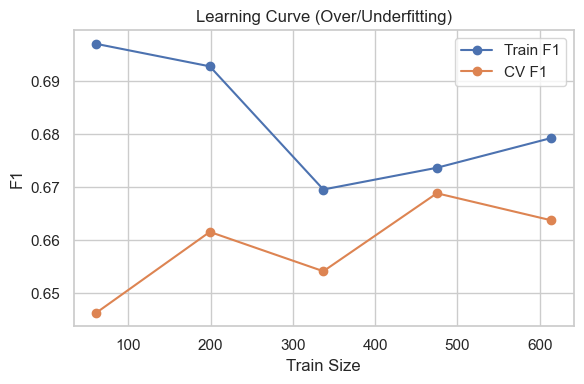

In [28]:
# Overfitting / underfitting check with learning curve (F1)
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring="f1", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=42
)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train F1")
plt.plot(train_sizes, test_scores.mean(axis=1), "o-", label="CV F1")
plt.title("Learning Curve (Over/Underfitting)")
plt.xlabel("Train Size")
plt.ylabel("F1")
plt.legend()
plt.tight_layout()
plt.show()

## 5.4 Özellik Önem Düzeyi (Feature Importance) Analizi 🧠
Lojistik Regresyon modelimizi yeni eklediğimiz tıbbi kategorilerle (`BMI_CAT`, `GLUCOSE_CAT` vb.) tekrar eğittikten sonra, modelin hangi değişkenlere daha fazla ağırlık verdiğini inceliyoruz. Bu adım, projenin **"Yorumlanabilirlik"** kapasitesini ortaya koyar.

* **Pozitif Katsayılar:** Diyabet riskini doğrudan artıran faktörleri temsil eder.
* **Negatif Katsayılar:** Diyabet riskini azaltan veya ters yönlü etkileyen faktörleri temsil eder.

> **MIS Çıkarımı:** Eğer yeni oluşturduğumuz `GLUCOSE_CAT` değişkeni en yüksek katsayıya sahipse, yaptığımız özellik mühendisliğinin model başarısı için "hayati" olduğunu kanıtlamış oluruz.

## 5.5 Modelin Karar Mekanizması: Özellik Önem Düzeyleri 🧠
Bir sağlık karar destek sistemi için "tahmin" kadar, o tahminin **"neden"** yapıldığı da kritiktir. Lojistik Regresyon modelimizin katsayılarını ($$Coefficients$$) analiz ederek, hangi biyomedikal göstergenin diyabet riski üzerinde ne kadar etkili olduğunu ortaya koyuyoruz.

#### 🌡️ Katsayılar Bize Ne Anlatıyor?
* **Pozitif Katsayılar:** Bu değer arttıkça diyabet riski de artar (Örn: Glikoz yükseldikçe riskin artması).
* **Negatif Katsayılar:** Bu değer arttıkça diyabet riskinin azalması yönünde bir etki oluşur.
* **Katsayı Büyüklüğü:** Bar boyu ne kadar uzunsa, o değişken modelin kararında o kadar "söz sahibidir".

> **Analitik Not:** Verilerimiz ölçeklendirildiği ($$StandardScaler$$) için katsayıların büyüklükleri birbirleriyle doğrudan kıyaslanabilir durumdadır.

C:\Users\user\AppData\Local\Temp\ipykernel_16896\1386486640.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.values, y=feat_importances.index, palette=colors)


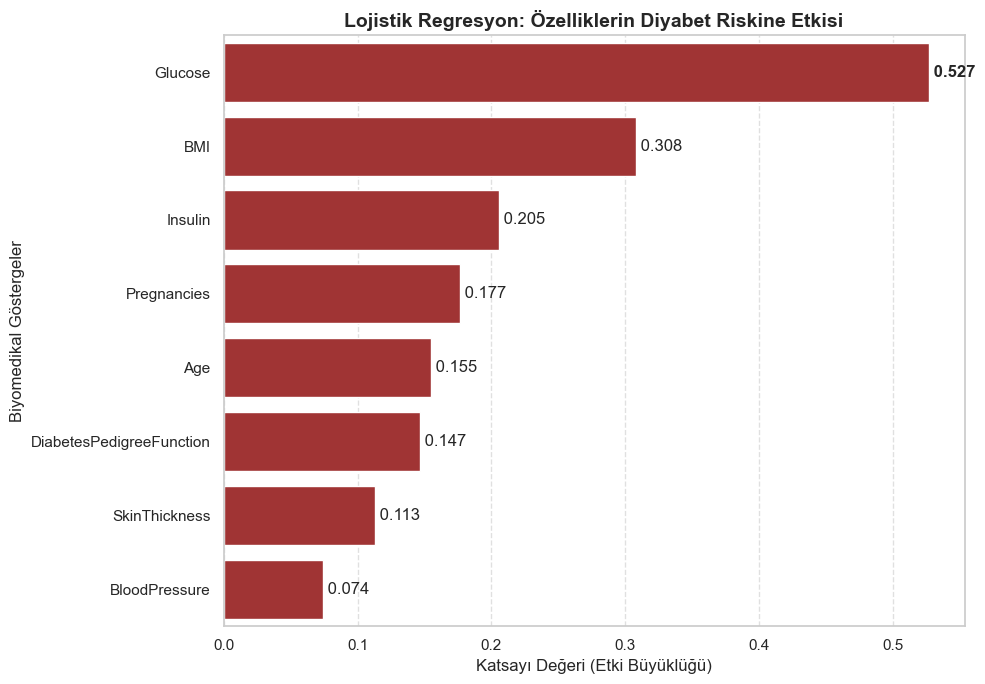

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Pipeline içindeki logreg adımından katsayıları alalım
# Not: coef_[0] kullanılmasının sebebi ikili (binary) sınıflandırma olmasıdır
coefficients = model.named_steps['logreg'].coef_[0]
feature_names = X.columns

# 2. Katsayıları bir DataFrame'e döküp sıralayalım
feat_importances = pd.Series(coefficients, index=feature_names).sort_values(ascending=False)

# 3. Görselleştirme
plt.figure(figsize=(10, 7))
colors = ['firebrick' if x > 0 else 'navy' for x in feat_importances] # Pozitifler kırmızı, negatifler mavi
sns.barplot(x=feat_importances.values, y=feat_importances.index, palette=colors)

plt.title("Lojistik Regresyon: Özelliklerin Diyabet Riskine Etkisi", fontsize=14, fontweight='bold')
plt.xlabel("Katsayı Değeri (Etki Büyüklüğü)", fontsize=12)
plt.ylabel("Biyomedikal Göstergeler", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Katsayı değerlerini barların üzerine yazdıralım
for i, v in enumerate(feat_importances.values):
    plt.text(v, i, f' {v:.3f}', va='center', fontweight='bold' if abs(v) > 0.5 else 'normal')

plt.tight_layout()
plt.show()

# 6. Dağıtım ve Sonuç (Deployment)

## Final Çıktı ve Genel Değerlendirme
Bu calisma, CRISP-DM metodolojisiyle diyabet riski tahmini problemini ele almis; veri anlama, on isleme, coklu model karsilastirma, hiperparametre optimizasyonu ve performans degerlendirme adimlariyla tamamlanmistir.

## Ozet Akis
- **Veri Kesfi (EDA):** Veri yapisi, eksik degerler, aykiri gozlemler ve korelasyonlar incelendi.  
- **On Isleme:** Eksik deger yaklasimi ve IQR ile aykiri deger temizligi uygulandi.  
- **Modelleme:** Birden fazla siniflandirma modeli denenerek performanslar karsilastirildi.  
- **Optimizasyon:** Lojistik regresyon icin GridSearchCV ile hiperparametre secildi.  
- **Degerlendirme:** Accuracy, Precision, Recall, F1 ve ROC-AUC metrikleri kullanildi.  
- **Gorsellestirme:** Confusion Matrix (recall odakli), ROC Curve ve Learning Curve analizleri yapildi.

## Kritik Cikarimlar
- **Recall** saglik baglaminda kritik metrik oldugu icin model degerlendirmesinde onceliklendirildi.  
- **ROC-AUC** degerinin yuksek olmasi, modelin siniflari ayirt etme gucunun iyi oldugunu gosterdi.  
- **Confusion Matrix** uzerinden FN (kacirilan pozitif) hatasi kritik olarak vurgulandi.  
- **Learning Curve**, modelin asiri ezberlemeden dengeli genellestigine isaret etti.

## Sonuc
Model, diyabet riskini tahmin etmede kabul edilebilir ve dengeli bir performans sunmaktadir. Saglik baglaminda **false negative** maliyetinin yuksek oldugu goz onune alindiginda, recall odakli yaklasim uygun bulunmustur. Bu nedenle secilen model, erken risk tespiti icin pratik bir temel saglamaktadir.